In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_excel("Praise Excel Sheet.xlsx")

In [4]:
df = pd.DataFrame(data)

In [6]:
df_log =df.copy()
num_cols = df.columns[1:]
df_log[num_cols] = df_log[num_cols].applymap(lambda x: np.log10(x)
                                                 if x > 0 
                                                 else np.nan)

In [7]:
df_log.head()

,School,Bacteria_Left_10^-3,Bacteria_Left_10^-6,Bacteria_Right_10^-3,Bacteria_Right_10^-6,Coliform_Left_10^-3,Coliform_Left_10^-6,Coliform_Right_10^-3,Coliform_Right_10^-6
0,School 1,5.127105,7.799341,5.324282,7.903090,4.770852,7.491362,4.799341,7.591065
1,School 2,5.082785,7.732394,5.255273,7.851258,4.623249,7.176091,4.698970,7.079181
2,School 3,5.100371,7.778151,5.158362,7.838849,4.556303,7.255273,4.643453,7.342423
3,School 4,4.986772,7.505150,5.041393,7.690196,4.602060,7.397940,4.672098,7.278754
4,School 5,5.235528,7.939519,5.382017,7.913814,4.518514,7.447158,4.623249,7.146128


COMPUTATION OF AVERAGES:

In [31]:
df_log.describe()

,Bacteria_Left_10^-3,Bacteria_Left_10^-6,Bacteria_Right_10^-3,Bacteria_Right_10^-6,Coliform_Left_10^-3,Coliform_Left_10^-6,Coliform_Right_10^-3,Coliform_Right_10^-6
count,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000
mean,5.063946,7.735628,5.160924,7.780835,4.557140,7.243518,4.668370,7.330653
std,0.163245,0.166894,0.202971,0.164774,0.192815,0.297565,0.076804,0.172826
min,4.785330,7.397940,4.857332,7.477121,4.079181,6.477121,4.505150,7.041393
25%,4.979997,7.622139,4.981681,7.694583,4.524996,7.215682,4.628359,7.217284
50%,5.075547,7.755875,5.120574,7.812913,4.602060,7.361728,4.672098,7.322219
75%,5.151598,7.840621,5.344885,7.908452,4.685719,7.423169,4.720140,7.491362
max,5.436163,7.963788,5.518514,8.041393,4.770852,7.491362,4.799341,7.591065


In [8]:
# Calculate Averages for 10^-3
avg_bacteria = df_log[["Bacteria_Left_10^-3", "Bacteria_Right_10^-3"]].mean()
avg_coliform = df_log[["Coliform_Left_10^-3", "Coliform_Right_10^-3"]].mean()

In [9]:
avg_bacteria

Bacteria_Left_10^-3     5.063946
Bacteria_Right_10^-3    5.160924
dtype: float64

In [10]:
avg_coliform

Coliform_Left_10^-3     4.55714
Coliform_Right_10^-3    4.66837
dtype: float64

In [11]:
# Calculate Averages for 10^-6
avg_bacteria2 = df_log[["Bacteria_Left_10^-6", "Bacteria_Right_10^-6"]].mean()
avg_coliform2 = df_log[["Coliform_Left_10^-6", "Coliform_Right_10^-6"]].mean()

In [12]:
avg_bacteria2

Bacteria_Left_10^-6     7.735628
Bacteria_Right_10^-6    7.780835
dtype: float64

In [13]:
avg_coliform2

Coliform_Left_10^-6     7.243518
Coliform_Right_10^-6    7.330653
dtype: float64

In [14]:
comparison_dilutions = {
    "Bacteria_10^-3": df_log[["Bacteria_Left_10^-3", "Bacteria_Right_10^-3"]].mean().mean(),
    "Bacteria_10^-6": df_log[["Bacteria_Left_10^-6", "Bacteria_Right_10^-6"]].mean().mean(),
    "Coliform_10^-3": df_log[["Coliform_Left_10^-3", "Coliform_Right_10^-3"]].mean().mean(),
    "Coliform_10^-6": df_log[["Coliform_Left_10^-6", "Coliform_Right_10^-6"]].mean().mean()
}

In [15]:
comparison_dilutions

{'Bacteria_10^-3': 5.112434813239322,
 'Bacteria_10^-6': 7.758231683090351,
 'Coliform_10^-3': 4.612755018211889,
 'Coliform_10^-6': 7.287085124715015}

IDENTIFYING TRENDS:

In [16]:
#Identify trends
highest_bacteria_school = df_log.loc[df[["Bacteria_Left_10^-3", "Bacteria_Right_10^-3"]].sum(axis=1).idxmax(), "School"]
lowest_bacteria_school = df_log.loc[df[["Bacteria_Left_10^-3", "Bacteria_Right_10^-3"]].sum(axis=1).idxmin(), "School"]

In [17]:
highest_bacteria_school

'School 13'

In [18]:
lowest_bacteria_school

'School 7'

COMPUTATION OF BAR CHARTS:

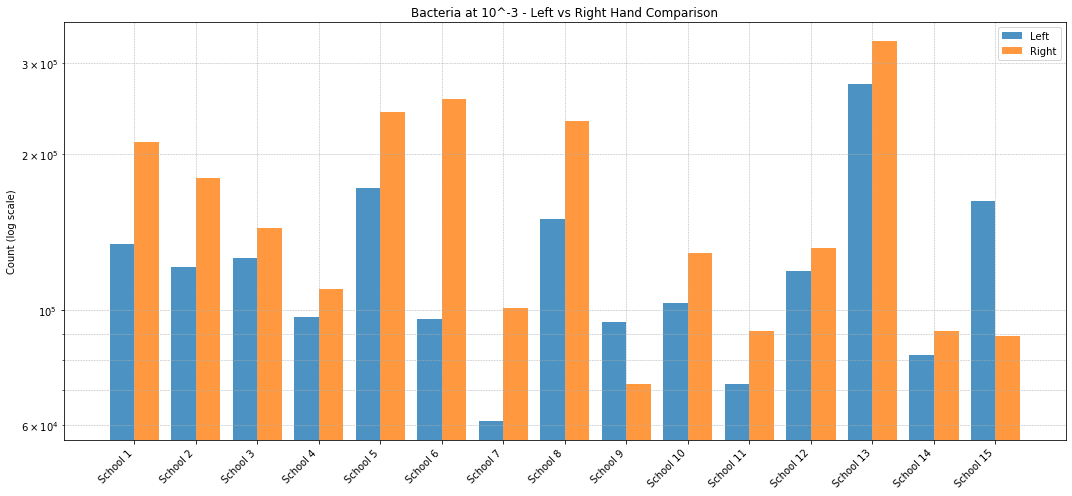

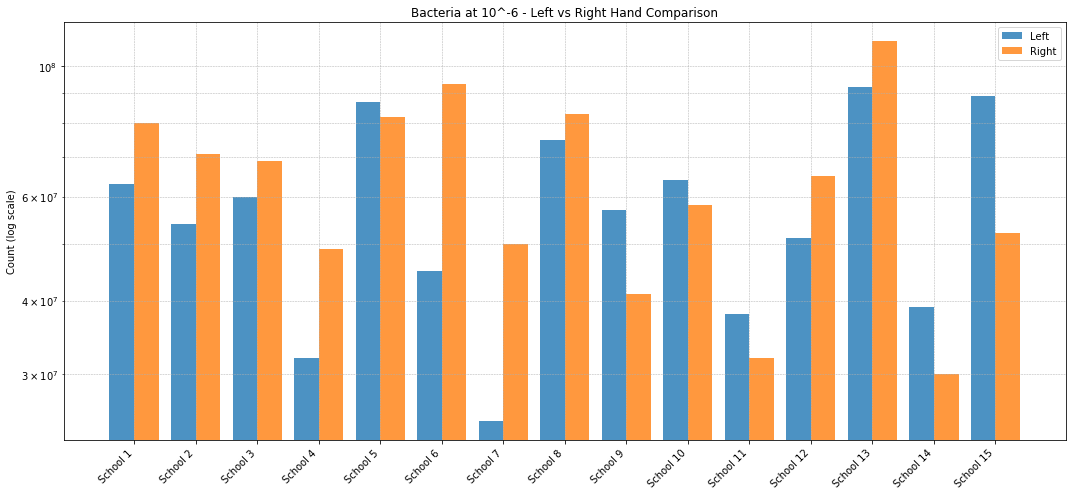

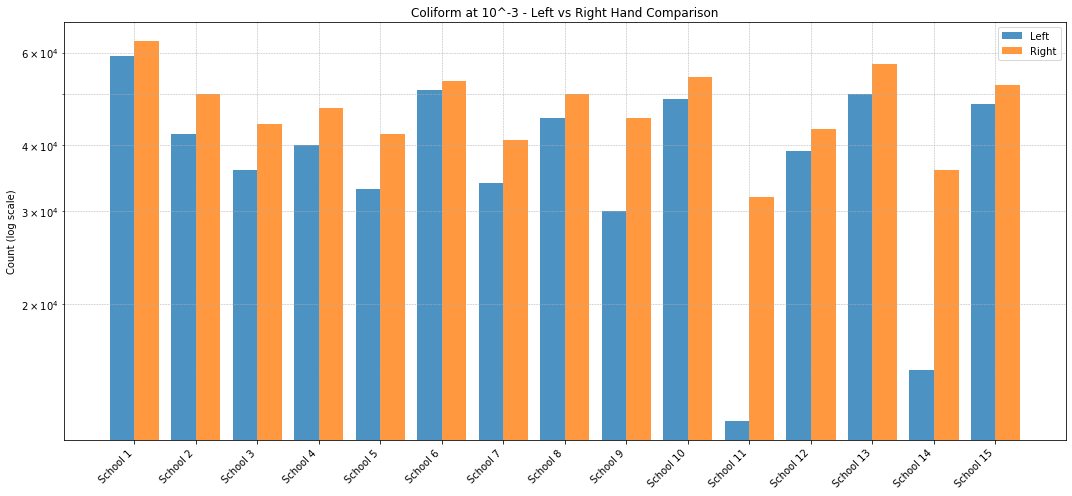

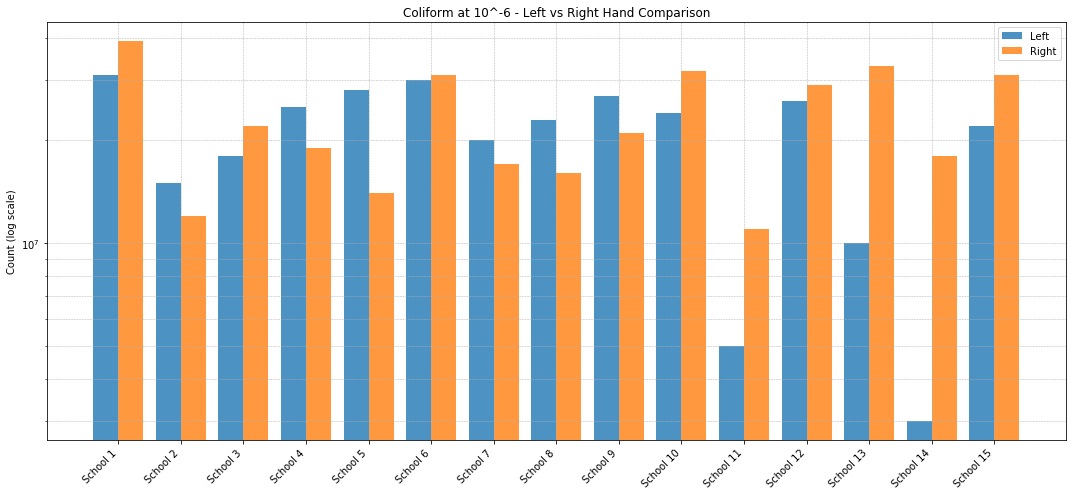

In [64]:
combinations = [ ('Bacteria at 10^-3', 'Bacteria_Left_10^-3', 'Bacteria_Right_10^-3'), ('Bacteria at 10^-6', 'Bacteria_Left_10^-6', 'Bacteria_Right_10^-6'), ('Coliform at 10^-3', 'Coliform_Left_10^-3', 'Coliform_Right_10^-3'), ('Coliform at 10^-6', 'Coliform_Left_10^-6', 'Coliform_Right_10^-6') ] # Generate plots 
for title_part, left_col, right_col in combinations: 
    plt.figure(figsize=(15, 7)) 
    schools = df['School'] 
    left = df[left_col] 
    right = df[right_col] 
    
    x = range(len(schools)) 
    width = 0.4 
    
    plt.bar(x, left, width, 
            label='Left', alpha=0.8) 
    plt.bar([p + width for p in x], 
            right, width, label='Right', alpha=0.8) 
    
    plt.xticks([p + width/2 for p in x], 
               schools, rotation=45, ha='right') 
    plt.yscale('log') 
    plt.ylabel('Count (log scale)') 
    plt.title(f'{title_part} - Left vs Right Hand Comparison') 
    plt.legend() 
    plt.grid(True, which='both', linestyle='--', linewidth=0.5) 
    plt.tight_layout() 
    plt.show()

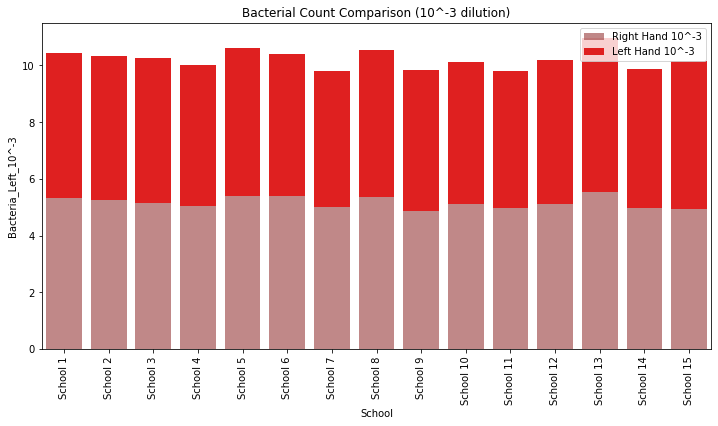

In [50]:
# Create bar charts to compare Bacteria left and right hands for 10^-3.
plt.figure(figsize=(12, 6))
sns.barplot(x=df_log["School"], y=df_log["Bacteria_Right_10^-3"],  color='brown', alpha=0.6, label='Right Hand 10^-3')
sns.barplot(x=df_log["School"], y=df_log["Bacteria_Left_10^-3"], bottom = df_log["Bacteria_Right_10^-3"], color='red', label='Left Hand 10^-3')
plt.xticks(rotation=90)
plt.legend()
plt.title("Bacterial Count Comparison (10^-3 dilution)")
plt.show()

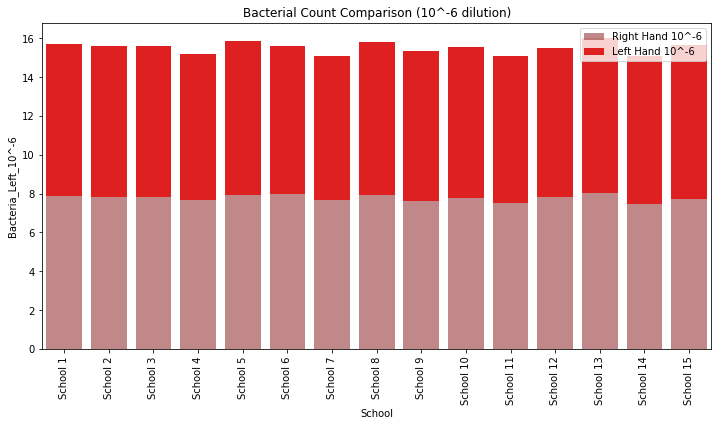

In [52]:
# Create bar charts to compare Bacteria left and right hands for 10^-6
plt.figure(figsize=(12, 6))
sns.barplot(x=df_log["School"], y=df_log["Bacteria_Right_10^-6"], color='brown', alpha=0.6, label='Right Hand 10^-6')
sns.barplot(x=df_log["School"], y=df_log["Bacteria_Left_10^-6"], bottom = df_log["Bacteria_Right_10^-6"], color='red', label='Left Hand 10^-6')
plt.xticks(rotation=90)
plt.legend()
plt.title("Bacterial Count Comparison (10^-6 dilution)")
plt.show()

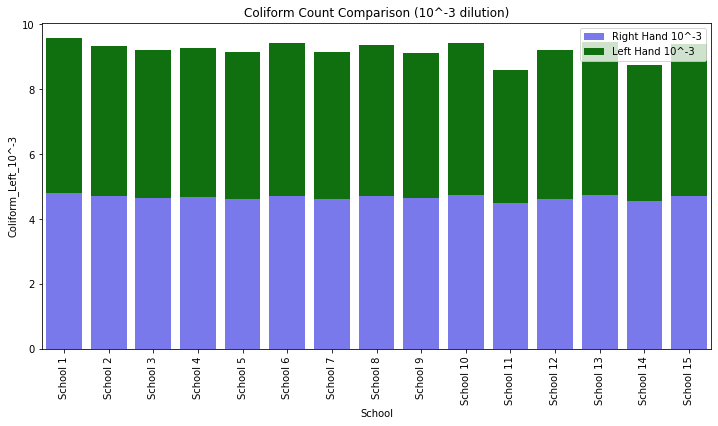

In [53]:
# Create bar charts to compare left and right hands for 10^-3.
plt.figure(figsize=(12, 6))
sns.barplot(x=df_log["School"], y=df_log["Coliform_Right_10^-3"], color='blue', alpha=0.6, label='Right Hand 10^-3')
sns.barplot(x=df_log["School"], y=df_log["Coliform_Left_10^-3"], bottom = df_log["Coliform_Right_10^-3"], color='green', label='Left Hand 10^-3')
plt.xticks(rotation=90)
plt.legend()
plt.title("Coliform Count Comparison (10^-3 dilution)")
plt.show()

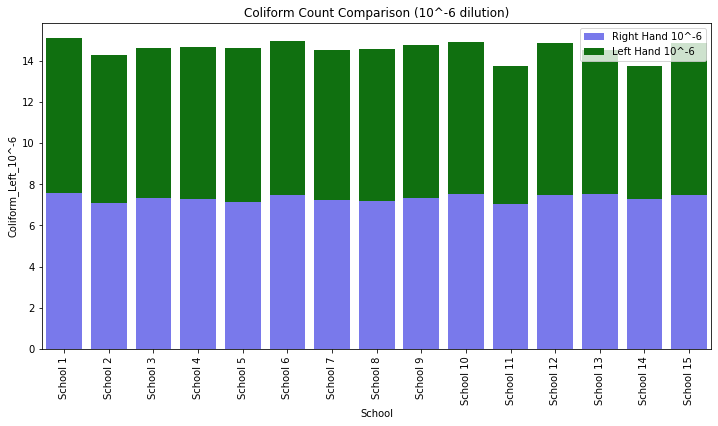

In [55]:
# Create bar charts to compare left and right hands for 10^-6.
plt.figure(figsize=(12, 6))
sns.barplot(x=df_log["School"], y=df_log["Coliform_Right_10^-6"], color='blue', alpha=0.6, label='Right Hand 10^-6')
sns.barplot(x=df_log["School"], y=df_log["Coliform_Left_10^-6"], bottom = df_log["Coliform_Right_10^-6"], color='green', label='Left Hand 10^-6')
plt.xticks(rotation=90)
plt.legend()
plt.title("Coliform Count Comparison (10^-6 dilution)")
plt.show()

COMPUTATION OF BOX PLOTS: 

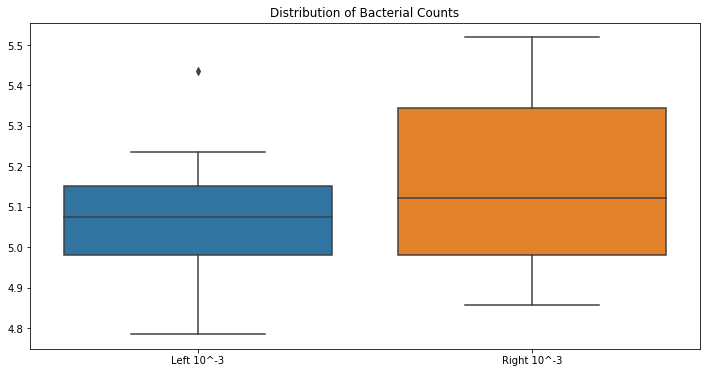

In [23]:
# Use box plots to show the Bacteria distribution of counts and identify outliers 10^-3

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_log[["Bacteria_Left_10^-3", "Bacteria_Right_10^-3"]])
plt.title("Distribution of Bacterial Counts")
plt.xticks(range(2), ["Left 10^-3", "Right 10^-3"])
plt.show()

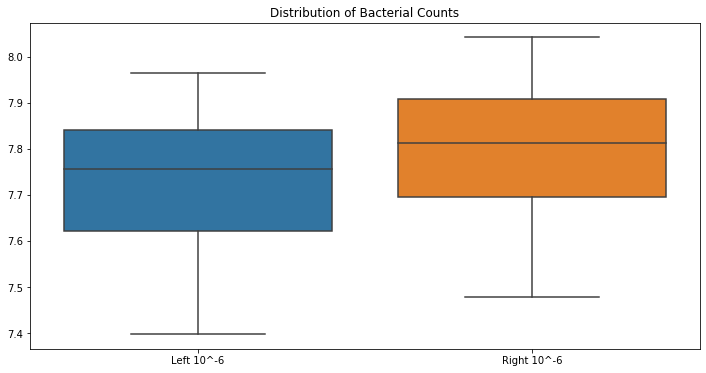

In [24]:
# Use box plots to show the Bacteria distribution of counts and identify outliers 10^-6
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_log[["Bacteria_Left_10^-6", "Bacteria_Right_10^-6"]])
plt.title("Distribution of Bacterial Counts")
plt.xticks(range(2), ["Left 10^-6", "Right 10^-6"])
plt.show()

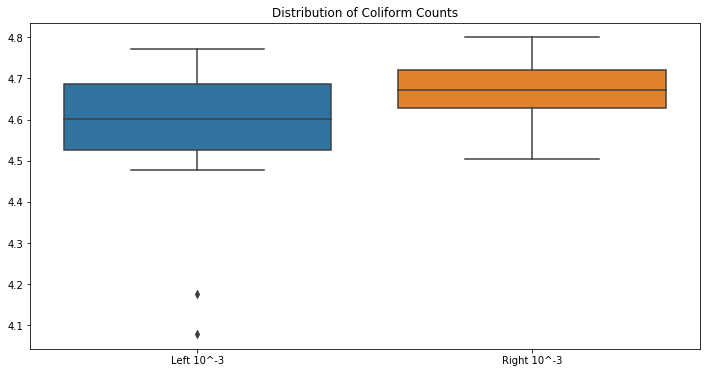

In [25]:
# Use box plots to show the Coliform distribution of counts and identify outliers 10^-3
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_log[["Coliform_Left_10^-3", "Coliform_Right_10^-3"]])
plt.title("Distribution of Coliform Counts")
plt.xticks(range(2), ["Left 10^-3", "Right 10^-3"])
plt.show()

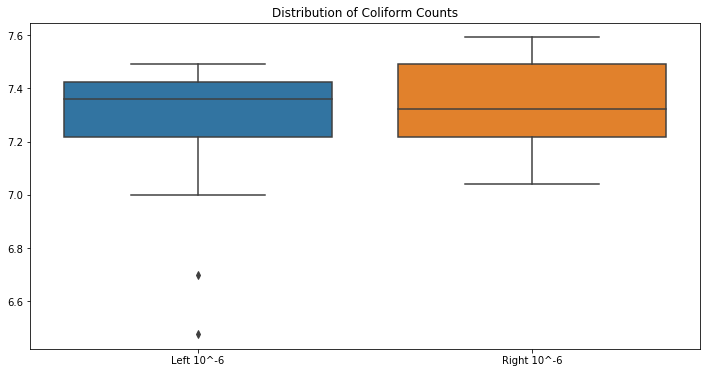

In [26]:
# Use box plots to show the Coliform distribution of counts and identify outliers 10^-6
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_log[["Coliform_Left_10^-6", "Coliform_Right_10^-6"]])
plt.title("Distribution of Coliform Counts")
plt.xticks(range(2), ["Left 10^-6", "Right 10^-6"])
plt.show()

COMPUTATION OF SCATTER PLOTS:

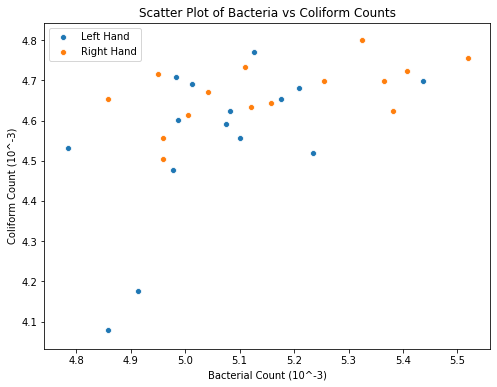

In [27]:
# •	Create scatter plots to see if there’s a relationship between bacterial and coliform counts for 10^-3.

plt.figure(figsize=(8, 6))
sns.scatterplot(x=df_log["Bacteria_Left_10^-3"], y=df_log["Coliform_Left_10^-3"], label="Left Hand")
sns.scatterplot(x=df_log["Bacteria_Right_10^-3"], y=df_log["Coliform_Right_10^-3"], label="Right Hand")
plt.title("Scatter Plot of Bacteria vs Coliform Counts")
plt.xlabel("Bacterial Count (10^-3)")
plt.ylabel("Coliform Count (10^-3)")
plt.legend()
plt.show()

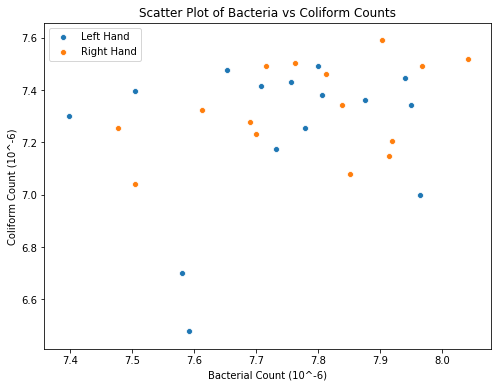

In [28]:
# Create scatter plots to see if there’s a relationship between bacterial and coliform counts for 10^-6
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df_log["Bacteria_Left_10^-6"], y=df_log["Coliform_Left_10^-6"], label="Left Hand")
sns.scatterplot(x=df_log["Bacteria_Right_10^-6"], y=df_log["Coliform_Right_10^-6"], label="Right Hand")
plt.title("Scatter Plot of Bacteria vs Coliform Counts")
plt.xlabel("Bacterial Count (10^-6)")
plt.ylabel("Coliform Count (10^-6)")
plt.legend()
plt.show()